# Examen Final
## Técnicas Multivariantes y Machine Learning
### Máster en Ingeniería Matemática y Computación
### Cuatrimestre III
**Alumno:** *Javier Blanco*




In [229]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import scipy.stats as stats
import statsmodels.api as sm
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import seaborn as sns
%matplotlib inline


#### Problema 1.

In [230]:
#Punto 1. Crear dataset:
date_birth = '06/01/1989'
np.random.seed(1989) 
m = 6+1
s1 = 6+0
s2 = np.random.randint(1,5)
a = 1989


X, y = make_regression(n_samples=500+m, 
                     n_features=10+s1+s2, 
                     n_informative=10+s1, 
                     noise=10*s1,
                     bias=2,
                     shuffle=False,
                     random_state=a)

10+s1+s2

19

In [231]:
# Punto 2: Análisis exploratorio
df = pd.DataFrame(X)
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       507 non-null    float64
 1   1       507 non-null    float64
 2   2       507 non-null    float64
 3   3       507 non-null    float64
 4   4       507 non-null    float64
 5   5       507 non-null    float64
 6   6       507 non-null    float64
 7   7       507 non-null    float64
 8   8       507 non-null    float64
 9   9       507 non-null    float64
 10  10      507 non-null    float64
 11  11      507 non-null    float64
 12  12      507 non-null    float64
 13  13      507 non-null    float64
 14  14      507 non-null    float64
 15  15      507 non-null    float64
 16  16      507 non-null    float64
 17  17      507 non-null    float64
 18  18      507 non-null    float64
dtypes: float64(19)
memory usage: 75.4 KB


(507, 19)

In [232]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000
mean,-0.053192,0.041767,-0.073055,0.005596,-0.056577,-0.004781,-0.006526,-0.005944,0.007788,0.036947,-0.012671,0.038168,0.039798,-0.033335,0.102690,0.067244,-0.043721,0.099240,0.001048
std,0.994105,0.920002,0.968166,0.992965,0.959768,0.978733,0.948223,0.994095,0.965404,1.001123,0.956600,1.066410,1.007224,0.992231,1.017711,0.939697,1.014810,0.976028,1.017893
min,-2.702508,-2.654457,-2.621065,-2.534989,-2.545163,-2.750540,-2.746327,-2.898069,-2.746215,-2.834822,-2.694054,-2.811754,-2.798266,-3.041767,-2.748588,-2.609885,-3.018521,-2.794922,-3.070894
25%,-0.695128,-0.565480,-0.735787,-0.671194,-0.729718,-0.698964,-0.621181,-0.687673,-0.660427,-0.659008,-0.672016,-0.702911,-0.645126,-0.760617,-0.577411,-0.523546,-0.755069,-0.562342,-0.659943
50%,-0.054484,0.006146,-0.053463,0.028110,-0.053141,-0.025695,-0.010575,-0.035391,0.041049,0.053506,-0.053425,0.046406,0.072589,-0.077396,0.131632,0.040820,-0.032729,0.132127,-0.007797
75%,0.598829,0.639420,0.550111,0.718019,0.602367,0.653042,0.611059,0.704632,0.711089,0.773855,0.706192,0.809246,0.744008,0.645662,0.753013,0.686332,0.687305,0.786813,0.712924
max,3.290431,3.607702,3.255687,2.692654,2.905089,2.855639,3.216654,3.129546,2.563964,3.252698,3.172914,3.041154,3.381700,2.743504,3.056996,2.763834,3.322096,2.833383,3.280818


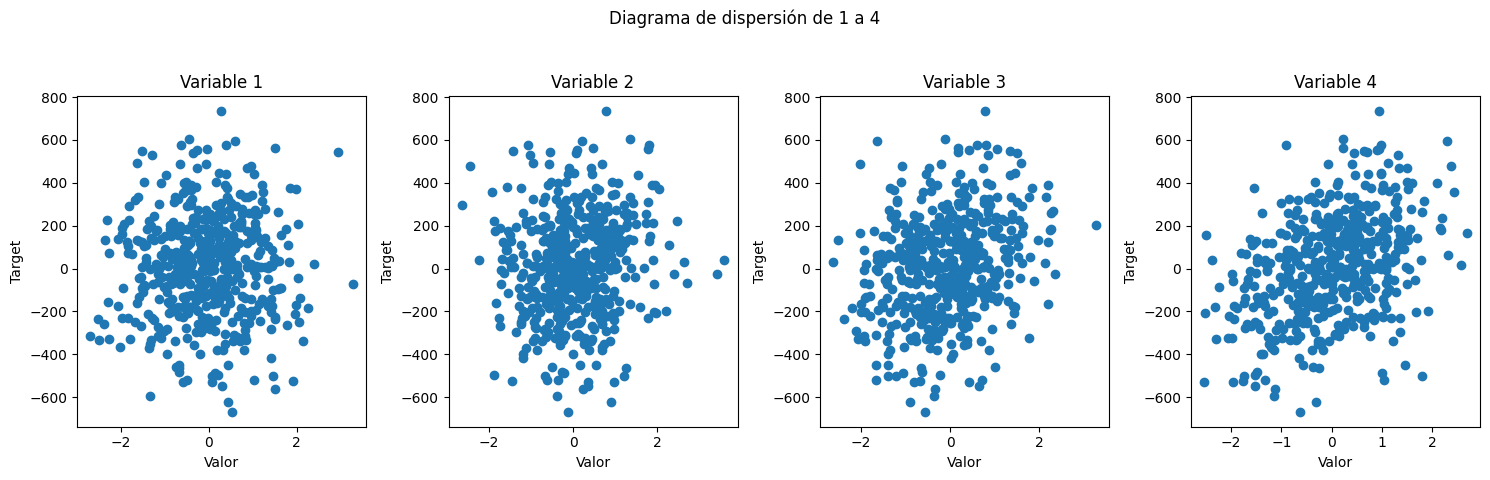

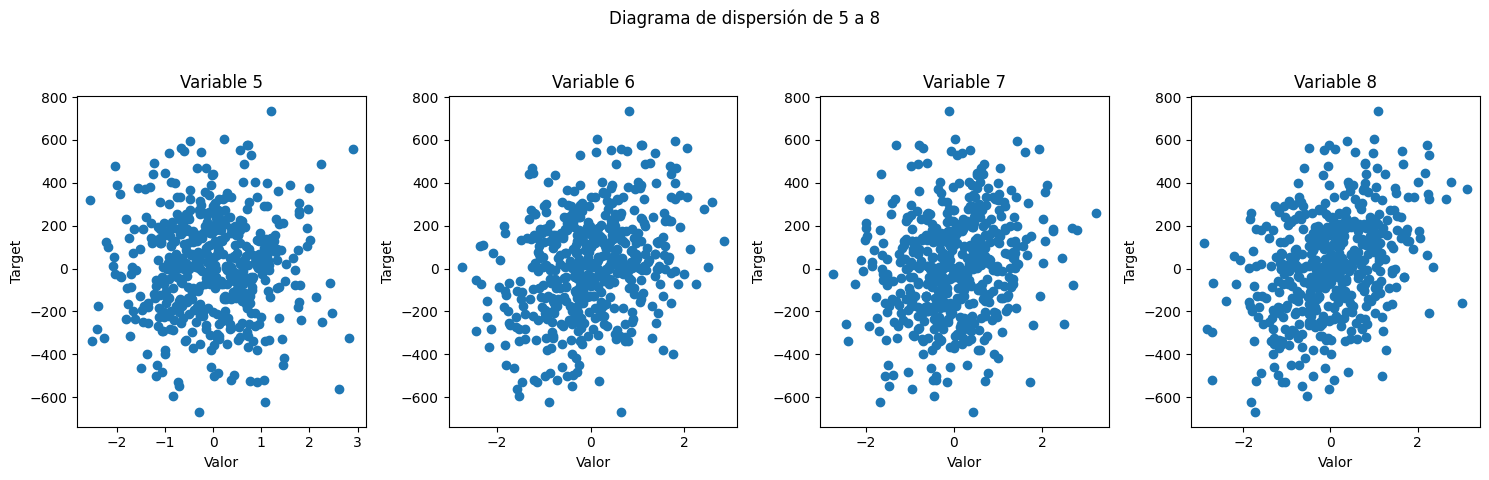

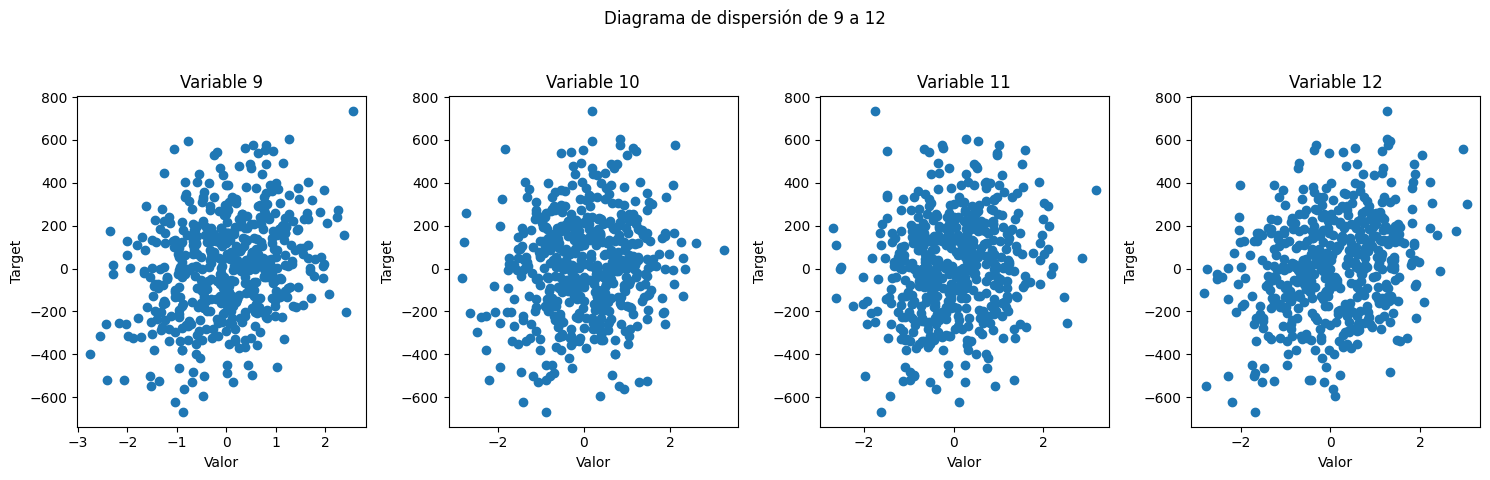

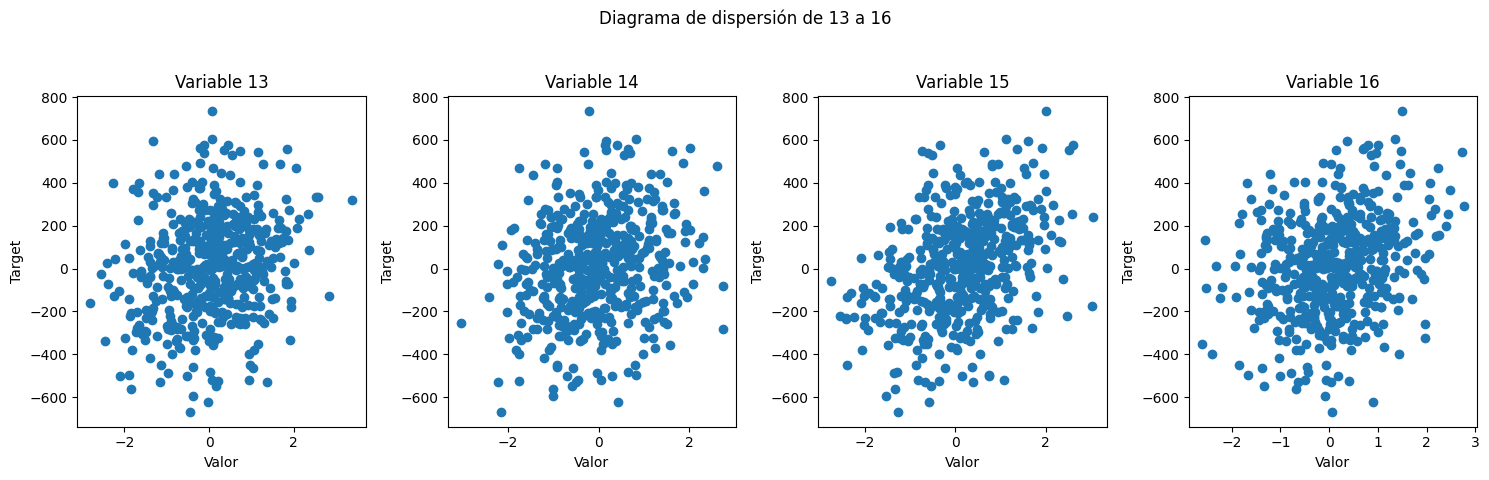

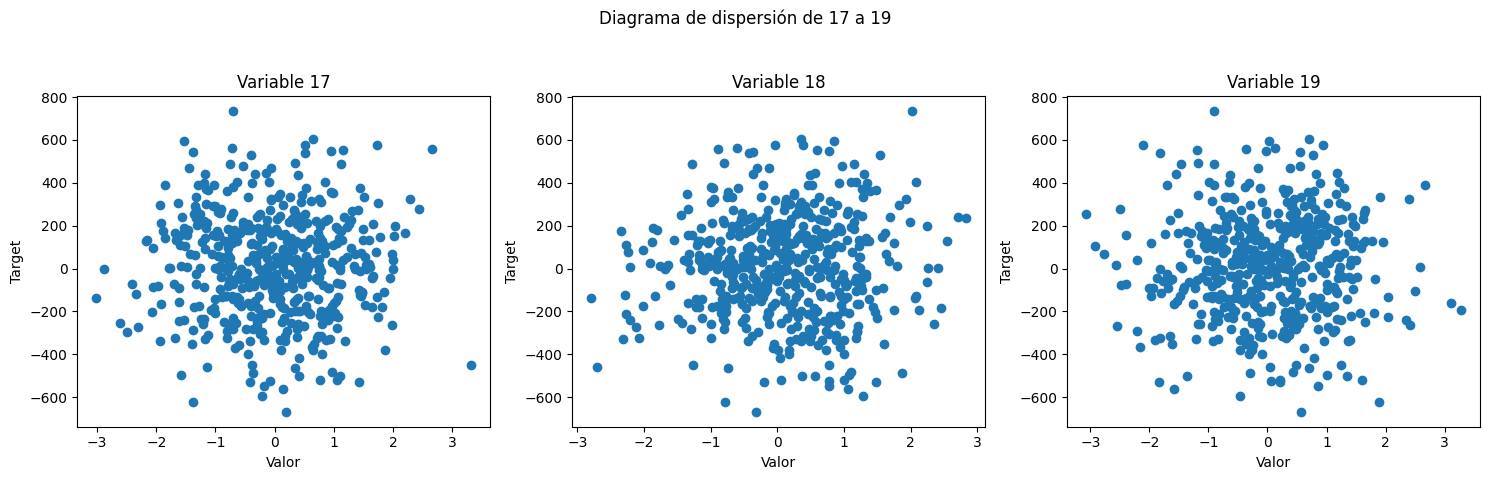

In [233]:
n_features = 10+s1+s2
# y = df['target']
for i in range(0, n_features, 4):
    fig, axes = plt.subplots(1, min(4, n_features - i), figsize=(15, 5)) # Subplots
    fig.suptitle(f'Diagrama de dispersión de {i+1} a {min(i + 4, n_features)}')

    for j in range(min(4, n_features - i)):
        axes[j].scatter(X[:, i + j], y)  # Scatter plot (dispersión)
        axes[j].set_title(f'Variable {i + j + 1}')
        axes[j].set_xlabel('Valor')
        axes[j].set_ylabel('Target')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajutando layout para evitar solape
    plt.show()

<Axes: >

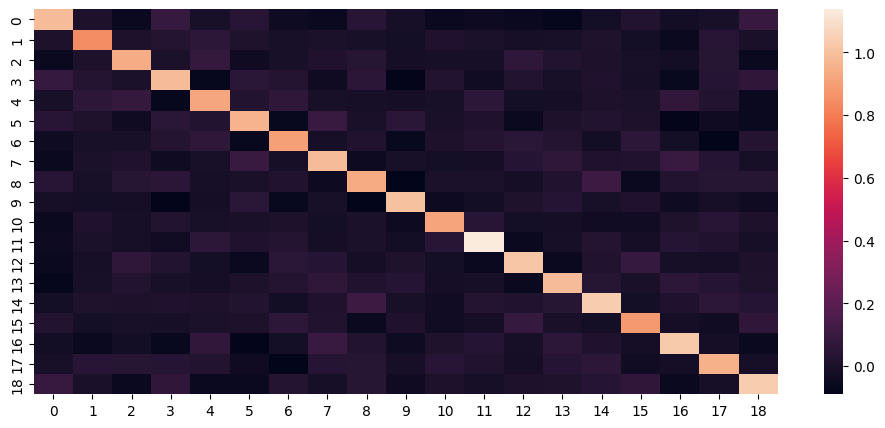

In [234]:
plt.figure(figsize=(12,5))
sns.heatmap(df.cov())

In [235]:
# Division del dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.18)



In [236]:
#Regresion Lineal multivariante
lm = LinearRegression()

model = lm.fit(X_train, y_train)
print('los coeficientes son:')
coefficients = model.coef_
intercept = model.intercept_

print("Coeficientes:", coefficients)
print("\n")
print("Intercepto:", intercept)

# Predicciones en el conjunto de validación
y_pred = model.predict(X_test)

# Evaluación del modelo
mse = mean_squared_error(y_test, y_pred) #Error cuadrático medio
r2 = r2_score(y_test, y_pred) # Bondad de ajuste

print("\n")
print("Error cuadrático medio:", mse)
print("R^2:", r2)

los coeficientes son:
Coeficientes: [15.6440722  27.07704541 60.4315993  89.50242889  2.47820683 63.26486175
 42.03920877 83.98524369 59.87622203 48.8607545  50.52148575 60.74155693
 40.60520085 41.99619563 84.01990105 68.85840463 -1.4797795  -4.51414467
 -4.9469873 ]


Intercepto: 1.3616317878069406


Error cuadrático medio: 3612.8165853426813
R^2: 0.935760180724994


In [237]:
# Método de Stepwise

def stepwise_selection(X, y,
                      initial_list=[],
                      threshold_in=0.01,
                      threshold_out=0.05,
                      verbose=True):
    """ Perform a forward-backward feature selection
    based on p-value from statsmodels.api.OLS
    Arguments:
        X - pandas.DataFrame with candidate features
        y - list-like with the target
        initial_list - list of features to start with (column names of X)
        threshold_in - include a feature if its p-value < threshold_in
        threshold_out - exclude a feature if its p-value > threshold_out
        verbose - whether to print the sequence of inclusions and exclusions
    Returns: list of selected features
    Always set threshold_in < threshold_out to avoid infinite looping.
    See https://en.wikipedia.org/wiki/Stepwise_regression for the details
    """
    # Obtenemos número de variables
    n_features = X.shape[1]

    max_iteration = n_features
    iteration = 0
    included = list(initial_list)

    while iteration < max_iteration:
        changed = False
        # Selección hacia delante
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]

        if len(new_pval) > 0:  # Verifica si hay candidato para añadir
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print('Agregando  {:30} con p-valor {:.8}'.format(best_feature, best_pval))

        # Selección hacia atrás
        if len(included) > 0:  # Verifica si hay variables candidatas para remover
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
            # usa todos los coeficientes menos el intercepto
            pvalues = model.pvalues.iloc[1:]
            if len(pvalues) > 0:  # verifica si hay p-valores por evaluar
                worst_pval = pvalues.max()
                if worst_pval > threshold_out:
                    changed = True
                    worst_feature = pvalues.idxmax()
                    included.remove(worst_feature)
                    if verbose:
                        print('Removiendo {:30} con p-valor {:.6}'.format(worst_feature, worst_pval))

        if not changed:
            break

        iteration += 1
    return included

step_wise_result = stepwise_selection(pd.DataFrame(X), pd.DataFrame(y))
print('Variables seleccionadas:')
print(step_wise_result)

Agregando                              14 con p-valor 7.5008924e-21
Agregando                               3 con p-valor 1.2614292e-21
Agregando                               7 con p-valor 9.1031373e-25
Agregando                              15 con p-valor 3.2727116e-16
Agregando                              11 con p-valor 9.4746577e-19
Agregando                               2 con p-valor 2.112319e-19
Agregando                               5 con p-valor 5.4540596e-22
Agregando                               8 con p-valor 1.1559138e-24
Agregando                               9 con p-valor 2.8138669e-20
Agregando                              10 con p-valor 1.5219042e-22
Agregando                               6 con p-valor 2.0774205e-25
Agregando                              13 con p-valor 2.5645951e-24
Agregando                              12 con p-valor 2.1482296e-32
Agregando                               1 con p-valor 8.8266453e-19
Agregando                               0 con p-v

In [238]:
#Modelo de Regreson con Stepwise
df_X = pd.DataFrame(X)
X_sw = df_X[step_wise_result]

# Dividimos el conjunto de datos en train y test
X_train_sw, X_test_sw, y_train, y_test = train_test_split(X_sw, y, test_size=0.18, random_state=a)


# Modelo de regresión lineal múltiple
model_sw = LinearRegression()
model_sw.fit(X_train_sw, y_train)

# Coeficientes e intercepto
coefficients_sw = model_sw.coef_
intercept_sw = model_sw.intercept_

print("Coeficientes:", coefficients_sw)
print("\n")
print("Intercepto:", intercept_sw)

# Predicciones en el conjunto de validación
y_pred_sw = model_sw.predict(X_test_sw)

# Evaluación del modelo
mse_sw = mean_squared_error(y_test, y_pred_sw) #Error cuadrático medio
r2_sw = r2_score(y_test, y_pred_sw) # Bondad de ajuste

print("\n")
print("Error cuadrático medio:", mse_sw)
print("R^2:", r2_sw)

Coeficientes: [84.1497206  90.26294364 84.47009188 70.33050877 61.53166868 59.28960873
 62.95760366 61.53505975 48.0215315  50.62803272 44.32290102 41.31893341
 39.25353642 25.64906883 12.03039117 -5.57163674]


Intercepto: -1.0989665937614141


Error cuadrático medio: 4067.6033914222317
R^2: 0.9178300495278152


In [239]:
#Regresión método Ridge
alpha = 10E3


ridge_model = Ridge(alpha=alpha)
ridge_model.fit(X_train, y_train)

# Predicciones con Ridge
y_pred_ridge = ridge_model.predict(X_test)

# Coeficientes e intercepto
coefficients_rg = ridge_model.coef_
intercept_rg = ridge_model.intercept_

print("Coeficientes:", coefficients_rg)
print("\n")
print("Intercepto:", intercept_rg)

# Validación del modelo

mse_rg = mean_squared_error(y_test, y_pred_ridge)
r2_rg = r2_score(y_test, y_pred_ridge)

resultados_ridge = {'mse': mse_rg, 'r2': r2_rg}
print(resultados_ridge)

Coeficientes: [ 0.14240037 -0.20202393  0.26931129 -0.07863897  0.18817941 -0.1804443
 -0.29880406 -0.13946368 -0.37666272 -0.98566912  0.11270274  0.09448765
  0.06043775  0.25789339 -0.15993243  0.04395696 -0.7675779  -0.26614325
  0.48133401]


Intercepto: 16.348613742312736
{'mse': 49811.6789692607, 'r2': -0.006249331601968722}


In [227]:
resultados_finales = {
    'Método': ['Lineal', 'Stepwise', 'Rigde'],
    'MSE': [mse, mse_sw, mse_rg],
    'R^2':[r2, r2_sw, r2_rg]
}

comparison_df = pd.DataFrame(resultados_finales)
comparison_df = comparison_df.set_index('Método')
comparison_df

,MSE,R^2
Método,,
Lineal,3612.816585,0.935760
Stepwise,4067.603391,0.917830
Rigde,49811.678969,-0.006249
